In [1]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('CNN_Articels_clean.csv')

In [3]:
df.head()

,Index,Author,Date published,Category,Section,Url,Headline,Description,Keywords,Second headline,Article text
0,0,"Jacopo Prisco, CNN",2021-07-15 02:46:59,news,world,https://www.cnn.com/2021/07/14/world/tusimple-...,"There's a shortage of truckers, but TuSimple t...",The e-commerce boom has exacerbated a global t...,"world, There's a shortage of truckers, but TuS...","There's a shortage of truckers, but TuSimple t...","(CNN)Right now, there's a shortage of truck d..."
1,1,"Stephanie Bailey, CNN",2021-05-12 07:52:09,news,world,https://www.cnn.com/2021/05/12/world/ironhand-...,Bioservo's robotic 'Ironhand' could protect fa...,Working in a factory can mean doing the same t...,"world, Bioservo's robotic 'Ironhand' could pro...",A robotic 'Ironhand' could protect factory wor...,(CNN)Working in a factory or warehouse can me...
2,2,"Words by Stephanie Bailey, video by Zahra Jamshed",2021-06-16 02:51:30,news,asia,https://www.cnn.com/2021/06/15/asia/swarm-robo...,This swarm of robots gets smarter the more it ...,"In a Hong Kong warehouse, a swarm of autonomou...","asia, This swarm of robots gets smarter the mo...",This swarm of robots gets smarter the more it ...,"(CNN)In a Hong Kong warehouse, a swarm of aut..."
3,3,Kathryn Vasel,2022-03-18 14:37:21,business,success,https://www.cnn.com/2022/03/18/success/pandemi...,"Two years later, remote work has changed milli...",Here's a look at how the pandemic reshaped peo...,"success, Two years later, remote work has chan...","Two years later, remote work has changed milli...",The pandemic thrust the working world into a n...
4,4,"Paul R. La Monica, CNN Business",2022-03-19 11:41:08,business,investing,https://www.cnn.com/2022/03/19/investing/march...,Why March is so volatile for stocks - CNN,March Madness isn't just for college basketbal...,"investing, Why March is so volatile for stocks...",Why March is so volatile for stocks,New York (CNN Business)March Madness isn't jus...


In [4]:
df.drop(columns = ['Index', 'Author', 'Date published', 'Url', 'Section', 'Second headline', 'Keywords', 'Description'], inplace=True, axis=1)

In [5]:
df.head()

,Category,Headline,Article text
0,news,"There's a shortage of truckers, but TuSimple t...","(CNN)Right now, there's a shortage of truck d..."
1,news,Bioservo's robotic 'Ironhand' could protect fa...,(CNN)Working in a factory or warehouse can me...
2,news,This swarm of robots gets smarter the more it ...,"(CNN)In a Hong Kong warehouse, a swarm of aut..."
3,business,"Two years later, remote work has changed milli...",The pandemic thrust the working world into a n...
4,business,Why March is so volatile for stocks - CNN,New York (CNN Business)March Madness isn't jus...


In [6]:
print(df['Category'].value_counts())

Category
news             18077
sport            15542
politics          2461
business           854
health             557
entertainment      413
travel              39
vr                   5
style                1
Name: count, dtype: int64


In [7]:
df.drop(df[(df['Category'] == 'style') | (df['Category'] == 'vr') | (df['Category'] == 'travel')].index, axis=0, inplace=True)

In [8]:
df['Category'].value_counts()

Category
news             18077
sport            15542
politics          2461
business           854
health             557
entertainment      413
Name: count, dtype: int64

In [9]:
df.head()

,Category,Headline,Article text
0,news,"There's a shortage of truckers, but TuSimple t...","(CNN)Right now, there's a shortage of truck d..."
1,news,Bioservo's robotic 'Ironhand' could protect fa...,(CNN)Working in a factory or warehouse can me...
2,news,This swarm of robots gets smarter the more it ...,"(CNN)In a Hong Kong warehouse, a swarm of aut..."
3,business,"Two years later, remote work has changed milli...",The pandemic thrust the working world into a n...
4,business,Why March is so volatile for stocks - CNN,New York (CNN Business)March Madness isn't jus...


In [10]:
df['Article text'][0]

' (CNN)Right now, there\'s a shortage of truck drivers in the US and worldwide, exacerbated by the e-commerce boom brought on by the pandemic. One solution to the problem is autonomous trucks, and several companies are in a race to be the first to launch one. Among them is San Diego-based TuSimple.Founded in 2015, TuSimple has completed about 2 million miles of road tests with its 70 prototype trucks across the US, China and Europe. Although these are simply commercially available trucks retrofitted with its technology, TuSimple has deals in place with two of the world\'s largest truck manufacturers -- Navistar in the US and Traton, Volkswagen\'s trucking business, in Europe -- to design and build fully autonomous models, which it hopes to launch by 2024. Photos: The Yara Birkeland is what its builders call the world\'s first zero-emission, autonomous cargo ship. The ship is scheduled to make its first journey between two Norwegian towns before the end of the year. Click through to see

In [11]:
df['Article text'] = df['Article text'].str.replace('(CNN)', '',)
df['Headline'] = df['Headline'].str.replace('- CNN', '',)

In [12]:
df['Article text'] =df['Article text'].str.strip()
df['Headline'] =df['Headline'].str.strip()

In [13]:
df['Article text']


0        Right now, there's a shortage of truck drivers...
1        Working in a factory or warehouse can mean doi...
2        In a Hong Kong warehouse, a swarm of autonomou...
3        The pandemic thrust the working world into a n...
4        New York (CNN Business)March Madness isn't jus...
                               ...                        
37944    Russian President Vladimir Putin has been stri...
37945    Lviv, Ukraine A long line of men snakes out of...
37946    Major League Baseball (MLB) is postponing its ...
37947    Here's a look at the life of Mikhail Gorbachev...
37948    Here's a look at the life of Her Royal Highnes...
Name: Article text, Length: 37904, dtype: object

In [14]:
df['Headline'][0]

"There's a shortage of truckers, but TuSimple thinks it has a solution: no driver needed"

In [15]:
df.head()

,Category,Headline,Article text
0,news,"There's a shortage of truckers, but TuSimple t...","Right now, there's a shortage of truck drivers..."
1,news,Bioservo's robotic 'Ironhand' could protect fa...,Working in a factory or warehouse can mean doi...
2,news,This swarm of robots gets smarter the more it ...,"In a Hong Kong warehouse, a swarm of autonomou..."
3,business,"Two years later, remote work has changed milli...",The pandemic thrust the working world into a n...
4,business,Why March is so volatile for stocks,New York (CNN Business)March Madness isn't jus...


In [16]:
y= df.pop('Category')
x = df['Headline']

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [18]:
x_train

37586    Nikola Jokic: I was a misfit when I joined the...
6182     Chicago Public Schools cancels classes for fou...
3496     Ron DeSantis holds on to his hopes of creating...
27554      LGCT Doha: Big Ben eyes double at season finals
28023    One state school has got 41 students into Oxfo...
                               ...                        
19705                U.S. Open 2015: Venus to meet Serena?
9778     Haiti gang leader threatens to kill captive mi...
19313       Vatican adjourns court  trial of ex-ambassador
31803    Paul Pogba isn't a 'prisoner,' agent Mino Raio...
16640    Even 'office cat' knew about hacking, ex-journ...
Name: Headline, Length: 30323, dtype: object

In [19]:
x.info()

<class 'pandas.core.series.Series'>
Index: 37904 entries, 0 to 37948
Series name: Headline
Non-Null Count  Dtype 
--------------  ----- 
37904 non-null  object
dtypes: object(1)
memory usage: 1.6+ MB


In [20]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

x_train = x_train.apply(clean_text)    

In [21]:
x_train

37586    nikola jokic i was a misfit when i joined the ...
6182     chicago public schools cancels classes for fou...
3496     ron desantis holds on to his hopes of creating...
27554       lgct doha big ben eyes double at season finals
28023    one state school has got students into oxford ...
                               ...                        
19705                         us open venus to meet serena
9778     haiti gang leader threatens to kill captive mi...
19313         vatican adjourns court trial of exambassador
31803    paul pogba isnt a prisoner agent mino raiola t...
16640    even office cat knew about hacking exjournalis...
Name: Headline, Length: 30323, dtype: object

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 20000
max_len = 15

### Adding the tokenizer which will convert these strings to numbers of sequences

tokenizer = Tokenizer(num_words= vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

sequences = tokenizer.texts_to_sequences(x_train)

In [23]:
sequences

[[8353, 10352, 115, 54, 7, 14059, 294, 115, 3397, 4, 7084, 17, 3194],
 [1361, 451, 1162, 2157, 8354, 6, 1054, 3863, 83],
 [3195,
  3015,
  993,
  9,
  2,
  37,
  611,
  5,
  3864,
  7,
  19,
  3610,
  2080,
  2586,
  3,
  568,
  10],
 [2718, 4916, 228, 1100, 900, 523, 11, 183, 382],
 [57, 174, 265, 44, 630, 569, 63, 2472, 8, 1673],
 [43,
  44,
  14060,
  385,
  231,
  1724,
  4149,
  4,
  4150,
  15,
  133,
  66,
  224,
  1077,
  2,
  6162],
 [994, 260, 6163, 73, 117, 15, 4488, 4489, 2587],
 [535, 175, 10353, 11, 10354, 3016],
 [29, 14061, 6164, 2255, 4490, 137, 251],
 [8355, 8356, 5459, 29, 390, 1362, 3, 3017, 15, 1325, 76],
 [45, 995, 265, 402, 5, 14062, 3, 141, 569, 6, 16, 3018],
 [3865, 61, 1725, 14063, 14064, 8357, 7, 690, 3398, 17, 1078],
 [622, 612, 29, 570, 4917, 5, 86, 451, 3196, 14065],
 [948, 1726, 402, 5, 284, 4151, 14066],
 [64, 25, 3019, 2863, 339, 5460, 3197, 3, 147, 72],
 [4152, 8358, 5, 14067, 56, 5461, 4153, 5, 8359, 195],
 [1189, 1576, 284, 326, 996, 34, 28, 867, 9, 

In [24]:
tokenizer.word_index

{'<OOV>': 1,
 'to': 2,
 'in': 3,
 'the': 4,
 'of': 5,
 'for': 6,
 'a': 7,
 'and': 8,
 'on': 9,
 'politics': 10,
 'at': 11,
 'after': 12,
 'is': 13,
 'as': 14,
 'with': 15,
 'us': 16,
 'says': 17,
 'from': 18,
 'new': 19,
 'world': 20,
 'by': 21,
 'over': 22,
 'uk': 23,
 'cup': 24,
 'open': 25,
 'how': 26,
 'are': 27,
 'be': 28,
 'police': 29,
 'opinion': 30,
 'first': 31,
 'win': 32,
 'covid': 33,
 'will': 34,
 'out': 35,
 'league': 36,
 'his': 37,
 'what': 38,
 'russia': 39,
 'it': 40,
 'up': 41,
 'who': 42,
 'trump': 43,
 'has': 44,
 'french': 45,
 'against': 46,
 'man': 47,
 'russian': 48,
 'ukraine': 49,
 'its': 50,
 'wins': 51,
 'about': 52,
 'coronavirus': 53,
 'was': 54,
 'more': 55,
 'not': 56,
 'one': 57,
 'star': 58,
 'but': 59,
 'why': 60,
 'attack': 61,
 'no': 62,
 'into': 63,
 'australian': 64,
 'brexit': 65,
 'could': 66,
 'court': 67,
 'he': 68,
 'olympics': 69,
 'title': 70,
 'an': 71,
 'final': 72,
 'manchester': 73,
 'this': 74,
 'london': 75,
 'death': 76,
 'back': 7

In [25]:
padded_headline = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

padded_headline

array([[ 8353, 10352,   115, ...,  3194,     0,     0],
       [ 1361,   451,  1162, ...,     0,     0,     0],
       [ 3195,  3015,   993, ...,  2080,  2586,     3],
       ...,
       [  541,     1,    67, ...,     0,     0,     0],
       [  774,  3118,   779, ...,     0,     0,     0],
       [  643,   746,  1935, ...,     0,     0,     0]])

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

In [27]:
le.classes_

array(['business', 'entertainment', 'health', 'news', 'politics', 'sport'],
      dtype=object)

In [28]:
padded_headline

array([[ 8353, 10352,   115, ...,  3194,     0,     0],
       [ 1361,   451,  1162, ...,     0,     0,     0],
       [ 3195,  3015,   993, ...,  2080,  2586,     3],
       ...,
       [  541,     1,    67, ...,     0,     0,     0],
       [  774,  3118,   779, ...,     0,     0,     0],
       [  643,   746,  1935, ...,     0,     0,     0]])

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
model = Sequential()
model.add(Embedding(vocab_size, 100, input_length=max_len))
model.add(Bidirectional(LSTM(150, return_sequences=True)))
model.add(Bidirectional(LSTM(100,)))
model.add(Dense(6, activation='softmax'))

c:\Users\kuchh\anaconda3\envs\gpu_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [31]:
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [32]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['Accuracy'])

In [33]:
model.fit(padded_headline, y_train_encoded, epochs=100, batch_size=32, validation_split=0.2, verbose=1,
          callbacks= [early])

Epoch 1/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 91s 109ms/step - Accuracy: 0.7493 - loss: 0.6630 - val_Accuracy: 0.9090 - val_loss: 0.3014
Epoch 2/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 86s 114ms/step - Accuracy: 0.9434 - loss: 0.1802 - val_Accuracy: 0.9077 - val_loss: 0.3061
Epoch 3/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 80s 105ms/step - Accuracy: 0.9718 - loss: 0.0925 - val_Accuracy: 0.8998 - val_loss: 0.3870
Epoch 4/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 76s 99ms/step - Accuracy: 0.9841 - loss: 0.0489 - val_Accuracy: 0.8989 - val_loss: 0.4023
Epoch 5/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 76s 100ms/step - Accuracy: 0.9913 - loss: 0.0293 - val_Accuracy: 0.8956 - val_loss: 0.4437
Epoch 6/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 78s 102ms/step - Accuracy: 0.9952 - loss: 0.0171 - val_Accuracy: 0.8978 - val_loss: 0.4629
Epoch 7/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 70s 92ms/step - Accuracy: 0.9953 - loss: 0.0155 - val_Accuracy: 0.8859 - val_loss: 0.6163
Epoch 8/100
759/759 ━━━━━━━━━━━━━━━━━━━━ 73s 96ms/step - Accuracy: 0.9974 - lo

In [34]:
model.save('News_Classification.keras')

In [35]:
def preprocess_text(data, tokenizer, max_len=max_len):
    sequences = tokenizer.texts_to_sequences(data)
    padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded

In [36]:
def classify(data):
    processed = preprocess_text(data, tokenizer, max_len)
    predictions = model.predict(processed)
    predicted_index = np.argmax(predictions, axis=1)
    final = le.inverse_transform(predicted_index)

    return final

In [37]:
test_pred = classify(x_test)

237/237 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step


In [38]:
test_pred

array(['business', 'news', 'news', ..., 'sport', 'sport', 'news'],
      dtype=object)

In [39]:
print(y_test)

975      business
30175        news
27979        news
6276         news
27389        news
           ...   
6398     business
33200        news
24534       sport
25293       sport
15610        news
Name: Category, Length: 7581, dtype: object


In [40]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

In [41]:
print(f1_score(y_test, test_pred, average='weighted'))

0.885335231656309


In [42]:
print(classification_report(y_test, test_pred))

               precision    recall  f1-score   support

     business       0.33      0.27      0.30       171
entertainment       0.39      0.16      0.22        83
       health       0.00      0.00      0.00       111
         news       0.88      0.94      0.91      3616
     politics       0.94      0.89      0.91       492
        sport       0.94      0.93      0.93      3108

     accuracy                           0.90      7581
    macro avg       0.58      0.53      0.55      7581
 weighted avg       0.88      0.90      0.89      7581



c:\Users\kuchh\anaconda3\envs\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kuchh\anaconda3\envs\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kuchh\anaconda3\envs\gpu_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

<Axes: >

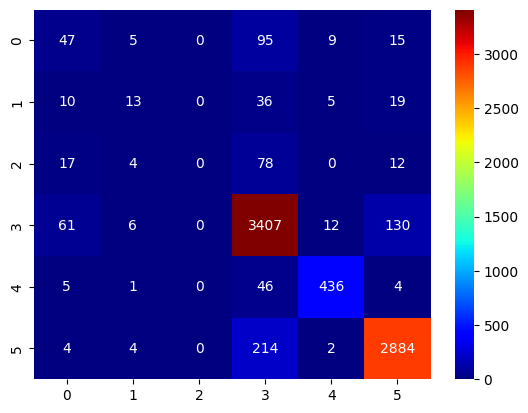

In [43]:
import seaborn as sns


sns.heatmap(confusion_matrix(y_test,test_pred), cmap='jet', annot=True,fmt='g')

In [44]:
import pickle as pkl

with open("tokenizer.pkl", 'wb') as file:
    pkl.dump(tokenizer, file)

with open('encoder.pkl', 'wb') as file:
    pkl.dump(le, file)